In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\luisa\\Documents\\LX1_GitHub_Repos\\ai_cheme_examples'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

In [3]:
data = pd.read_excel('data/2.1-zw-Pyrolysis_Data 6-16_Reduced.xlsx').drop(['Unnamed: 0'], axis=1)

data.head()

,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,11FC05043PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,52221.634263,8326.643312,8514.593137,8772.479316,8702.662279,8725.061214,8925.859148,4231.776051,4235.679965,4331.376363,...,611.155410,617.949135,835.685702,832.775546,837.579875,835.185782,837.532533,840.083022,1014.203860,838.564984
1,52265.900328,8365.639417,8556.450386,8785.182039,8691.885549,8703.588278,8947.979539,4234.084322,4235.981084,4331.812712,...,608.830187,615.503000,842.786275,857.657809,842.063391,831.472131,827.847198,829.859649,1003.212185,838.303879
2,52175.422216,8399.151486,8958.929290,8866.258307,8568.940794,8487.709325,8657.917877,4219.596998,4227.073918,4335.506624,...,612.223660,619.237611,832.882358,829.082685,836.141160,835.556342,839.504382,844.880867,1012.859396,837.527600
3,52301.058592,8371.304905,8755.843789,8816.456687,8648.966226,8614.722260,8805.725760,4235.860665,4242.020290,4330.784367,...,610.773671,617.620987,836.430164,833.785133,840.057993,838.177957,834.462237,833.534243,1011.943218,837.818136
4,52294.353809,8395.126075,8939.937799,8868.780738,8602.885921,8493.646648,8679.958967,4240.078093,4221.425555,4324.309267,...,610.275413,617.500575,839.643744,851.533809,842.807576,835.302639,827.123134,825.370441,1005.692422,837.338927


In [4]:
from sklearn import preprocessing

x = data.values #returns a numpy array
min_max_scaler = preprocessing.MinMaxScaler()
standard_scaler = preprocessing.StandardScaler()
x_min_max_scaled = min_max_scaler.fit_transform(x)
x_standard_scaled = standard_scaler.fit_transform(x)

min_max_data = pd.DataFrame(x_min_max_scaled)
min_max_data.columns = data.columns
standard_data = pd.DataFrame(x_standard_scaled)
standard_data.columns = data.columns

In [5]:
print(data.head())
print(min_max_data.head())
print(standard_data.head())

    11FI05101PV  11FC05031PV1  11FC05032PV1  11FC05033PV1  11FC05034PV1  \
0  52221.634263   8326.643312   8514.593137   8772.479316   8702.662279   
1  52265.900328   8365.639417   8556.450386   8785.182039   8691.885549   
2  52175.422216   8399.151486   8958.929290   8866.258307   8568.940794   
3  52301.058592   8371.304905   8755.843789   8816.456687   8648.966226   
4  52294.353809   8395.126075   8939.937799   8868.780738   8602.885921   

   11FC05035PV1  11FC05036PV1  11FC05041PV1  11FC05042PV1  11FC05043PV1  ...  \
0   8725.061214   8925.859148   4231.776051   4235.679965   4331.376363  ...   
1   8703.588278   8947.979539   4234.084322   4235.981084   4331.812712  ...   
2   8487.709325   8657.917877   4219.596998   4227.073918   4335.506624  ...   
3   8614.722260   8805.725760   4235.860665   4242.020290   4330.784367  ...   
4   8493.646648   8679.958967   4240.078093   4221.425555   4324.309267  ...   

   11TI05005PV  11TI05006PV  11TDC05011PV1  11TDC05012PV1  11TDC0501

In [28]:
def plot_distribution(data, color = 'b'):

    fig = plt.figure(figsize=(15, 6))

    axes = []

    if data is not None:
        for i, col in enumerate(data.columns):
            ax = fig.add_subplot(len(data.columns), int(np.floor(len(data.columns) + 1)), i+1)
            lr = min(data[col].values)

            ur = max(data[col].values)

            data[col].plot.hist(ax = ax, bins = 25, range=[lr, ur], color = color)
            ax.set_xlabel(f'{col}', labelpad = 10, fontsize='x-large')
            ax.set_ylabel('')

            ax.grid(False)

            axes.append(ax)


    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 

    plt.tight_layout()

    plt.show()

    return None


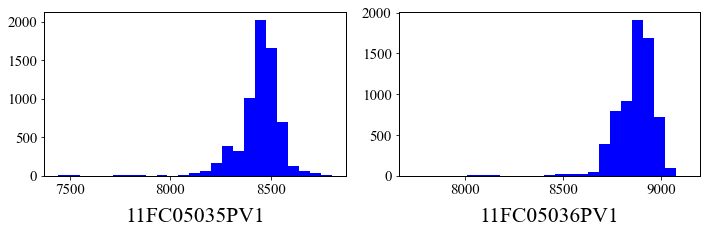

In [34]:
plot_distribution(data.iloc[:, 5:7])

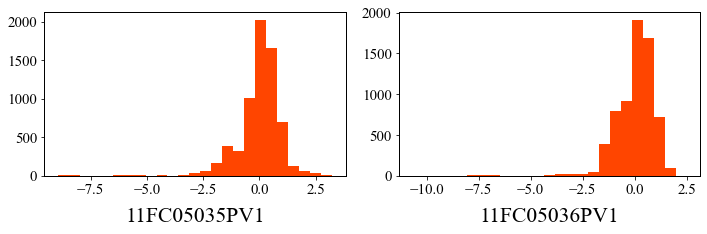

In [35]:
plot_distribution(standard_data.iloc[:, 5:7], color = 'orangered')

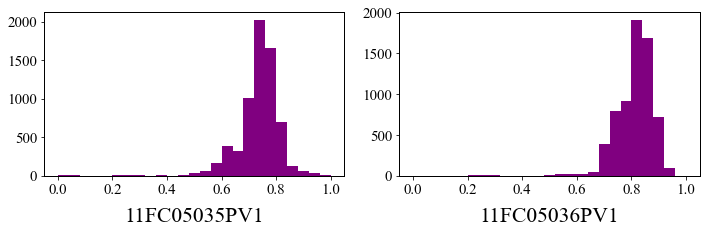

In [36]:
plot_distribution(min_max_data.iloc[:, 5:7], color = 'purple')